## Phase 2 – Model Training

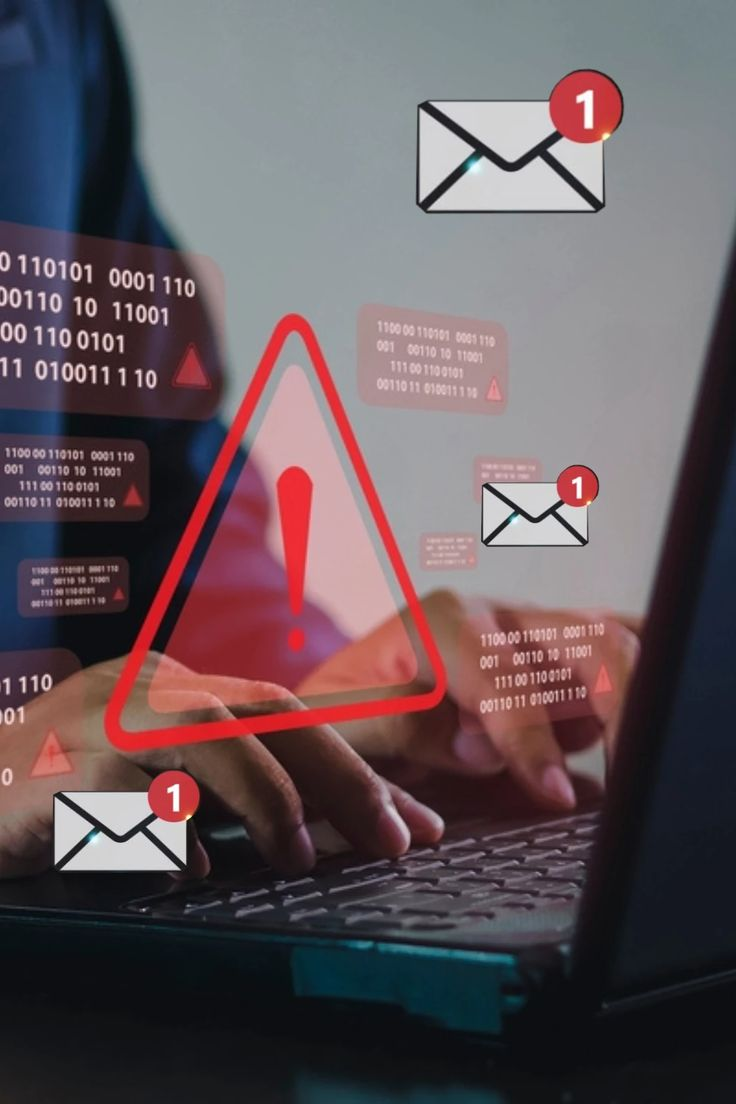


In this phase, we focused on training different machine learning models using the preprocessed data from Phase 1.  
The main goal was to prepare and train our models so we can later evaluate them and decide which one works best for detecting the spam emails.

We decided to test three models that are commonly used and well-known for text classification:

1. **Logistic Regression** – a simple but powerful baseline model that usually performs very well with TF-IDF text data.  
2. **Linear SVM (Support Vector Machine)** – works great with high-dimensional features and can handle TF-IDF vectors efficiently.  
3. **Naive Bayes (optional)** – a lightweight model that trains quickly and provides a good point of comparison for more complex algorithms.

We chose these models because they are effective, easy to interpret, and well-suited for spam or phishing detection tasks.


## 📋 Work Distribution Table

| Step | Task Description | Assigned To | Subtasks / Notes |
|------|------------------|--------------|------------------|
| **1** | **Data Preparation & Notebook Review** | **Renad** | • Split data into **train** and **testing** sets.<br>• Review data preprocessing notebook, findings .<br>• Suggest suitable **models** for training.<br>_Note: The “train-testing” split will be further divided into train/eval._ |
| **2** | **Model Selection & Training** | **Salha & Rawan** | • Pick model.<br>• Train the model using **train** and **eval** sets.<br>• Record and document **training metrics**. |
| **3** | **Model Evaluation** | **Rahaf** | • Evaluate the final model using the **testing** set.<br>• Generate **performance metrics** (Precision, Recall, F1, Confusion Matrix, etc.).<br>• Summarize and interpret the results. |
| **4** | **Feature Importance Analysis** | **Fajr** | • Determine **feature importance** using the trained model.<br>• Create visualizations (e.g., SHAP, bar charts).<br>• Write an **insight summary** explaining feature impact. |


### Data Loading and Splitting

Now we start by importing our data and splitting it into training and testing sets.    
We’re using the same data split for all models so that every model is trained and tested on identical data.      
This way, later when we compare their performance, the results will be fair and consistent.

In [1]:
# import the libraries we’ll need
import joblib
from sklearn.model_selection import train_test_split

# load the feature data from Phase 1 (TF-IDF + numeric features)
data = joblib.load("artifacts/feature_data.joblib")
X = data["X"]
y = data["y"]

print("Data loaded successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

# split our data into train/test once (we’ll use the same for all models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Data loaded successfully
X shape: (39139, 5015)
y shape: (39139,)
Train: (31311, 5015)  Test: (7828, 5015)


### Logistic Regression

We started with Logistic Regression because it’s often a strong baseline model for binary classification.  
It’s simple, fast, and works really well with large TF-IDF datasets.  
Here, we train it and show the results just to confirm that it’s working —  
We’ll explain these results in more detail later in the evaluation section of this phase.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Create the Logistic Regression model
log_model = LogisticRegression(max_iter=2000, random_state=42)

# Define hyperparameter values to try
param_grid = {
    'C': [0.01, 0.1, 1, 10],       # Regularization strength
    'solver': ['liblinear', 'saga'] # Different solvers
}

# Set up GridSearchCV with 3-fold cross-validation
grid_log = GridSearchCV(log_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Print training start message
print("Training Logistic Regression")  

# Train the model using Grid Search
grid_log.fit(X_train, y_train)
print("Model trained successfully")  # Keep the post-training message

# Print best parameters found during search
print("Best parameters:", grid_log.best_params_)
print("Best CV score:", round(grid_log.best_score_ * 100, 2), "%")

# Test the model on new/unseen data
y_pred = grid_log.predict(X_test)

# Compute accuracy and print classification report
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Training Logistic Regression


/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reac

Model trained successfully
Best parameters: {'C': 10, 'solver': 'liblinear'}
Best CV score: 99.68 %
Test Accuracy: 99.76 %

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3462
           1       1.00      1.00      1.00      4366

    accuracy                           1.00      7828
   macro avg       1.00      1.00      1.00      7828
weighted avg       1.00      1.00      1.00      7828



### Linear SVM (Support Vector Machine)

Next, we trained a Linear SVM model.  
This model is great for high-dimensional data like our TF-IDF features.  
We also used Grid Search with Cross Validation to find the best hyperparameter “C” value and to make sure we don’t overfit.  
Again, we’re only checking that it trains and runs properly — we’ll analyze its performance later.

In [3]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# define our SVM model and parameter grid
param_grid = {'C': [0.1, 1, 10]}
svm = LinearSVC(max_iter=2000, random_state=42)

# use GridSearchCV to find the best C value
grid = GridSearchCV(svm, param_grid, cv=3, n_jobs=-1)
print("Training and tuning Linear SVM...")
grid.fit(X_train, y_train)

# print the best parameters and validation score
print("Best parameters:", grid.best_params_)
print("Best CV score:", round(grid.best_score_ * 100, 2), "%")

# test on unseen data
y_pred_svm = grid.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("Test Accuracy:", round(acc_svm * 100, 2), "%")

# quick report just to confirm it’s working
print("\n for verification only We’ll explain results in detail later in the evaluation section\n")
print(classification_report(y_test, y_pred_svm))



Training and tuning Linear SVM...
Best parameters: {'C': 10}
Best CV score: 99.8 %
Test Accuracy: 99.83 %

 for verification only We’ll explain results in detail later in the evaluation section

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3462
           1       1.00      1.00      1.00      4366

    accuracy                           1.00      7828
   macro avg       1.00      1.00      1.00      7828
weighted avg       1.00      1.00      1.00      7828



### Naive Bayes 

Lastly, we trained a Naive Bayes model as one more way to test our data.
It’s a simple and fast algorithm that uses probabilities to decide whether an email is phishing or not.
Even though it’s not as complex as the other models, it’s still helpful for seeing how a quick, lightweight method performs in comparison.

In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Create Naive Bayes model
nb = MultinomialNB()

# Print training start message
print("Training Naive Bayes...")

# Define Grid Search with hyperparameter alpha
param_grid_nb = {'alpha': [0.1, 0.5, 1.0, 2.0]}

# Set up GridSearchCV with 3-fold cross-validation
grid_nb = GridSearchCV(nb, param_grid_nb, cv=3, scoring='accuracy', n_jobs=-1)

# Train the model using Grid Search
grid_nb.fit(X_train, y_train)
print("Model trained successfully!")

# Print best parameters found during search
print("Best parameters:", grid_nb.best_params_)
print("Best CV score:", round(grid_nb.best_score_ * 100, 2), "%")

# Test the model on unseen data
y_pred_nb = grid_nb.predict(X_test)

# Compute accuracy and print classification report
acc_nb = accuracy_score(y_test, y_pred_nb)
print("Test Accuracy:", round(acc_nb * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Training Naive Bayes...
Model trained successfully!
Best parameters: {'alpha': 2.0}
Best CV score: 99.42 %
Test Accuracy: 99.43 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       1.00      0.99      0.99      4366

    accuracy                           0.99      7828
   macro avg       0.99      0.99      0.99      7828
weighted avg       0.99      0.99      0.99      7828



### Model Evaluation  

After training all three models  Logistic Regression, Linear SVM, and Naive Bayes 
this section focuses on evaluating and comparing using model evaluation metrics

The main objective here is to determine which model performs best overall and is therefore the most suitable for phishing email detection.
We use standard classification metrics Accuracy, Precision, Recall, and F1-score to ensure that our evaluation captures every important aspect of model performance, including reliability and consistency on unseen data.

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Compute evaluation metrics for all models
metrics = {
    "Model": ["Logistic Regression", "Linear SVM", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted"),
        precision_score(y_test, y_pred_nb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted"),
        recall_score(y_test, y_pred_nb, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test, y_pred_nb, average="weighted")
    ]
}

# Create a clean summary table
df_metrics = pd.DataFrame(metrics)
df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]] = (
    df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]].round(4)
)

print(" Model Evaluation Results:\n")
display(df_metrics)


 Model Evaluation Results:



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9976,0.9976,0.9976,0.9976
1,Linear SVM,0.9983,0.9983,0.9983,0.9983
2,Naive Bayes,0.9943,0.9943,0.9943,0.9943


### Metric Comparison
The most important metric is Recall, as it indicates how many actual phishing or spam  emails the model successfully identified.


If the Recall is low, it means the model is missing some phishing emails and that can be risky, since those missed emails could harm users or compromise security.
It’s better for the model to flag a few safe emails by mistake than to let a dangerous one pass through.
So, in our case, a higher Recall value means better protection and a more reliable system

In [6]:
# Create a clean summary table
df_metrics = pd.DataFrame(metrics)
df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]] = (
    df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]].round(4)
)

print(" Model Evaluation Results:\n")
display(df_metrics)


 Model Evaluation Results:



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9976,0.9976,0.9976,0.9976
1,Linear SVM,0.9983,0.9983,0.9983,0.9983
2,Naive Bayes,0.9943,0.9943,0.9943,0.9943


Both Logistic Regression and Linear SVM showed outstanding performance, achieving almost perfect scores across all evaluation metrics.
However, Linear SVM performed slightly better in every category including Accuracy, Precision, Recall, and F1-Score.
Even though the improvement is small, it still indicates that the Linear SVM model makes more correct predictions overall and generalizes a bit better to unseen data.

Since our main goal is to detect as many phishing emails as possible, Recall is the most important metric.
A higher Recall means the model can correctly identify more phishing emails without missing any — which is crucial for maintaining security and preventing real threats from slipping through.
Linear SVM achieved a slightly higher Recall (0.9983 vs 0.9976), showing it’s more sensitive in detecting phishing messages.


### Final Decision

Based on these results, Linear SVM was selected as the final model for phishing email detection.
It provides the best balance between accuracy, Recall, and reliability, making it the most suitable choice

### Coefficient-Based Feature Importance 

Since our final model is **Linear SVM**, we can understand what features had the most impact on its predictions.  
This type of model gives a weight to every feature, showing how much it pushes the prediction toward spam or not spam.

In **Phase 1**, we combined the email **subject** and **body** into one column called `combined_text` and used TF-IDF to turn the text into numeric features.  
Each of these features represents a word, and its weight in the model shows how important that word is.

Positive weights mean the word pushes the model toward **spam**, while negative weights push toward **not spam**.  
By looking at these weights, we can tell which words had the strongest influence on the model’s decisions.


In [7]:
# --- Word-level Feature Importance for Linear SVM ---
import joblib
import numpy as np
import pandas as pd
from scipy.sparse import issparse

# Load vectorizer and data
vec = joblib.load("artifacts/tfidf_vectorizer.joblib")   # same vectorizer used in Phase 1
data = joblib.load("artifacts/feature_data.joblib")      # contains X and y (X = [TF-IDF + numeric])
X = data["X"]
y = data["y"]

# Load the best trained SVM model from GridSearchCV
svm_best = grid.best_estimator_

# Get feature names from TF-IDF and the number of text features
feature_names = np.array(vec.get_feature_names_out())
n_text = feature_names.shape[0]

# Get model coefficients and flatten them
coef = svm_best.coef_
if issparse(coef):
    coef = coef.toarray()
coef = coef.ravel()

# Focus only on the text part (exclude numeric features)
coef_text = coef[:n_text]

# Get top positive and negative weights
top_k = 20
pos_idx = np.argpartition(coef_text, -top_k)[-top_k:]
pos_idx = pos_idx[np.argsort(coef_text[pos_idx])[::-1]]
neg_idx = np.argpartition(coef_text, top_k)[:top_k]
neg_idx = neg_idx[np.argsort(coef_text[neg_idx])]

top_spam = pd.DataFrame({
    "feature": feature_names[pos_idx],
    "weight": coef_text[pos_idx]
}).reset_index(drop=True)

top_notspam = pd.DataFrame({
    "feature": feature_names[neg_idx],
    "weight": coef_text[neg_idx]
}).reset_index(drop=True)

print("Top features driving SPAM (positive weights):")
display(top_spam)

print("Top features driving NOT SPAM (negative weights):")
display(top_notspam)


Top features driving SPAM (positive weights):


/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/fuvi/Desktop/SWE485-Project-Group1/.venv/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,feature,weight
0,bank,2.032683
1,love,2.021296
2,payment,1.715016
3,custom alert,1.626183
4,partner,1.479700
5,keeping,1.433728
6,dollars,1.428648
7,custom,1.415556
8,won file,1.374651
9,debt,1.365619


Top features driving NOT SPAM (negative weights):


,feature,weight
0,tony,-3.487112
1,html,-2.512590
2,trade,-2.204004
3,thanks,-2.078996
4,emails,-1.908823
5,viruses,-1.856184
6,spam,-1.822174
7,channel,-1.807949
8,email,-1.797633
9,people,-1.754626


### Results and Observations 

From the results, the model gave higher positive weights to words like **“bank”**, **“payment”**, **“won”**, and **“debt”**.  
These are common words in spam emails, especially the ones related to money or urgent actions, so they pushed the model toward predicting spam.

On the other hand, words like **“thanks”**, **“newsletter”**, **“people”**, and **“date”** had negative weights, meaning they usually appear in normal or safe emails.  
So when the model sees these words, it predicts not spam.

Overall, this shows that the Linear SVM successfully learned real spam patterns.
It focused on financial or alert-related words and ignored casual or harmless ones, which explains why it achieved such a high recall.



### Findings, and notes from the evaluation
All models achieved accuracy scores between 99% and 100%, which at first seemed perfect. However, this level of performance is suspiciously high and indicates a case of data leakage.

In the preprocessing phase, the TF-IDF vectorizer and the scaler were fitted on the entire dataset (df) before splitting into train and test sets. This caused the models to “see” information from the test data during training, allowing them to memorize patterns instead of truly generalizing.

I detected this issue because precision and recall values were nearly identical and extremely high, which is unusual in most realistic scenarios, these metrics tend to vary or trade off against each other.

### small fix: lets edit the TFIDF step in the preprocess

### keep all code runs on the old preprocess and fix the preprocess then copy all code above  and run in after this cell to show how we fixed the data lekage,to show them we analyzed it